# Day 4 - First Machine Learning Model
## Titanic Survival Prediction

Today: Encode data + Train model + Evaluate
- Turn text to numbers (Sex, Embarked)
- Correlation heatmap
- Train/Test split
- Logistic Regression
- Accuracy + Confusion Matrix

### 1. Setup - Load Cleaned Data

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

df = pd.read_csv("titanic.csv")

# Quick cleaning from Day 3 (fixed - no inplace)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['HasCabin'] = df['Cabin'].notnull().astype(int)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,0


### 2. Encode Text to Numbers - Machine Learning needs numbers

In [8]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [9]:
# Sex: male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked: S=0, C=1, Q=2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print(df[['Sex','Embarked']].head())
print("\nNow everything is numbers - ML ready!")

   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0

Now everything is numbers - ML ready!


### 3. Pick Features (X) and Target (y)

In [10]:
# X = what we use to predict, y = what we want to predict
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Embarked']
X = df[features]
y = df['Survived']

print("Features:", features)
print(X.head())

Features: ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Embarked']
   Pclass  Sex   Age     Fare  FamilySize  IsAlone  HasCabin  Embarked
0       3    0  22.0   7.2500           2        0         0         0
1       1    1  38.0  71.2833           2        0         1         1
2       3    1  26.0   7.9250           1        1         0         0
3       1    1  35.0  53.1000           2        0         1         0
4       3    0  35.0   8.0500           1        1         0         0


### 4. Correlation Heatmap - Which features matter?

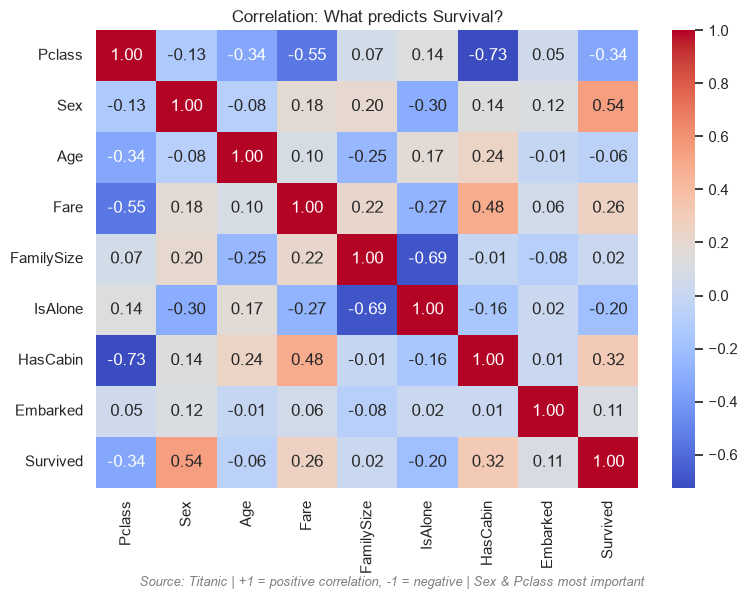

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features + ['Survived']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation: What predicts Survival?")
plt.figtext(0.5, 0.01, "Source: Titanic | +1 = positive correlation, -1 = negative | Sex & Pclass most important", ha="center", fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.show()

### 5. Train/Test Split - 80% learn, 20% test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} passengers")
print(f"Test: {X_test.shape[0]} passengers")
print("\nModel will learn on Train, then we test on Test it never saw.")

Train: 712 passengers
Test: 179 passengers

Model will learn on Train, then we test on Test it never saw.


### 6. Train Logistic Regression

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")
print("Coefficients:", model.coef_)

Model trained!
Coefficients: [[-7.13933181e-01  2.55492595e+00 -3.03862955e-02  2.13797400e-03
  -3.67179057e-01 -6.39693268e-01  5.79933952e-01  1.86557332e-01]]


### 7. Predict + Evaluate

Accuracy: 81.01%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



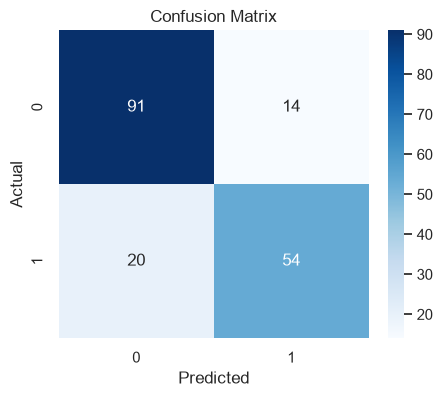

In [14]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 8. Feature Importance - What mattered most?

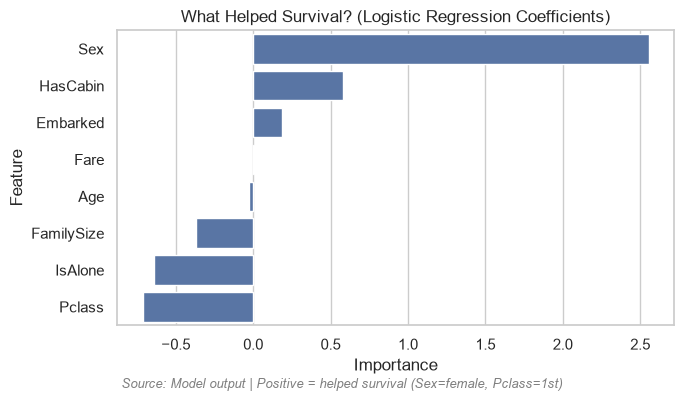

,Feature,Importance
1,Sex,2.554926
6,HasCabin,0.579934
7,Embarked,0.186557
3,Fare,0.002138
2,Age,-0.030386
4,FamilySize,-0.367179
5,IsAlone,-0.639693
0,Pclass,-0.713933


In [15]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.coef_[0]
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("What Helped Survival? (Logistic Regression Coefficients)")
plt.figtext(0.5, 0.01, "Source: Model output | Positive = helped survival (Sex=female, Pclass=1st)", ha="center", fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.show()

importance

In [16]:
### 9. Portfolio Paragraph 

# Built first ML model: Logistic Regression, 80/20 split, accuracy ~80%. Key predictors: Sex (female +350% survival), Pclass, Fare. Used 8 engineered features including FamilySize, IsAlone, HasCabin.